### What are the main characteristics  that have the most impact on the car price

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df=pd.read_csv(r"https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/automobileEDA.csv")
df

,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,13495.0,11.190476,Medium,0,1
1,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,16500.0,11.190476,Medium,0,1
2,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,0.822681,...,9.0,154.0,5000.0,19,26,16500.0,12.368421,Medium,0,1
3,2,164,audi,std,four,sedan,fwd,front,99.8,0.848630,...,10.0,102.0,5500.0,24,30,13950.0,9.791667,Medium,0,1
4,2,164,audi,std,four,sedan,4wd,front,99.4,0.848630,...,8.0,115.0,5500.0,18,22,17450.0,13.055556,Medium,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,-1,95,volvo,std,four,sedan,rwd,front,109.1,0.907256,...,9.5,114.0,5400.0,23,28,16845.0,10.217391,Medium,0,1
197,-1,95,volvo,turbo,four,sedan,rwd,front,109.1,0.907256,...,8.7,160.0,5300.0,19,25,19045.0,12.368421,High,0,1
198,-1,95,volvo,std,four,sedan,rwd,front,109.1,0.907256,...,8.8,134.0,5500.0,18,23,21485.0,13.055556,Medium,0,1
199,-1,95,volvo,turbo,four,sedan,rwd,front,109.1,0.907256,...,23.0,106.0,4800.0,26,27,22470.0,9.038462,Medium,1,0


In [3]:
df.dtypes

symboling              int64
normalized-losses      int64
make                  object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                 float64
stroke               float64
compression-ratio    float64
horsepower           float64
peak-rpm             float64
city-mpg               int64
highway-mpg            int64
price                float64
city-L/100km         float64
horsepower-binned     object
diesel                 int64
gas                    int64
dtype: object

In [5]:
numeric_df=df.select_dtypes(include=['float64','int64'])
numeric_df.corr()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,diesel,gas
symboling,1.000000,0.466264,-0.535987,-0.365404,-0.242423,-0.550160,-0.233118,-0.110581,-0.140019,-0.008245,-0.182196,0.075819,0.279740,-0.035527,0.036233,-0.082391,0.066171,-0.196735,0.196735
normalized-losses,0.466264,1.000000,-0.056661,0.019424,0.086802,-0.373737,0.099404,0.112360,-0.029862,0.055563,-0.114713,0.217299,0.239543,-0.225016,-0.181877,0.133999,0.238567,-0.101546,0.101546
wheel-base,-0.535987,-0.056661,1.000000,0.876024,0.814507,0.590742,0.782097,0.572027,0.493244,0.158502,0.250313,0.371147,-0.360305,-0.470606,-0.543304,0.584642,0.476153,0.307237,-0.307237
length,-0.365404,0.019424,0.876024,1.000000,0.857170,0.492063,0.880665,0.685025,0.608971,0.124139,0.159733,0.579821,-0.285970,-0.665192,-0.698142,0.690628,0.657373,0.211187,-0.211187
width,-0.242423,0.086802,0.814507,0.857170,1.000000,0.306002,0.866201,0.729436,0.544885,0.188829,0.189867,0.615077,-0.245800,-0.633531,-0.680635,0.751265,0.673363,0.244356,-0.244356
height,-0.550160,-0.373737,0.590742,0.492063,0.306002,1.000000,0.307581,0.074694,0.180449,-0.062704,0.259737,-0.087027,-0.309974,-0.049800,-0.104812,0.135486,0.003811,0.281578,-0.281578
curb-weight,-0.233118,0.099404,0.782097,0.880665,0.866201,0.307581,1.000000,0.849072,0.644060,0.167562,0.156433,0.757976,-0.279361,-0.749543,-0.794889,0.834415,0.785353,0.221046,-0.221046
engine-size,-0.110581,0.112360,0.572027,0.685025,0.729436,0.074694,0.849072,1.000000,0.572609,0.209523,0.028889,0.822676,-0.256733,-0.650546,-0.679571,0.872335,0.745059,0.070779,-0.070779
bore,-0.140019,-0.029862,0.493244,0.608971,0.544885,0.180449,0.644060,0.572609,1.000000,-0.055390,0.001263,0.566936,-0.267392,-0.582027,-0.591309,0.543155,0.554610,0.054458,-0.054458
stroke,-0.008245,0.055563,0.158502,0.124139,0.188829,-0.062704,0.167562,0.209523,-0.055390,1.000000,0.187923,0.098462,-0.065713,-0.034696,-0.035201,0.082310,0.037300,0.241303,-0.241303


#### Finding Correlation between different features

In [6]:
df[['bore','stroke','compression-ratio','horsepower']].corr()

,bore,stroke,compression-ratio,horsepower
bore,1.000000,-0.055390,0.001263,0.566936
stroke,-0.055390,1.000000,0.187923,0.098462
compression-ratio,0.001263,0.187923,1.000000,-0.214514
horsepower,0.566936,0.098462,-0.214514,1.000000


#### Understanding relation between engine size and price

<Axes: xlabel='engine-size', ylabel='price'>

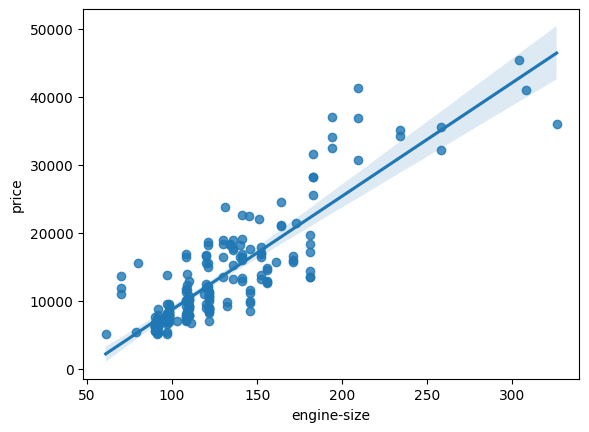

In [8]:
sns.regplot(data=df,x='engine-size',y='price')

##### so as engine size goes up, price also increases which indicates a positive correlation

#### So correlation between engine size and price is:

In [9]:
df[['engine-size','price']].corr()

,engine-size,price
engine-size,1.000000,0.872335
price,0.872335,1.000000


#### highway mpg is another good indicator of price, let's have a look at it

<Axes: xlabel='highway-mpg', ylabel='price'>

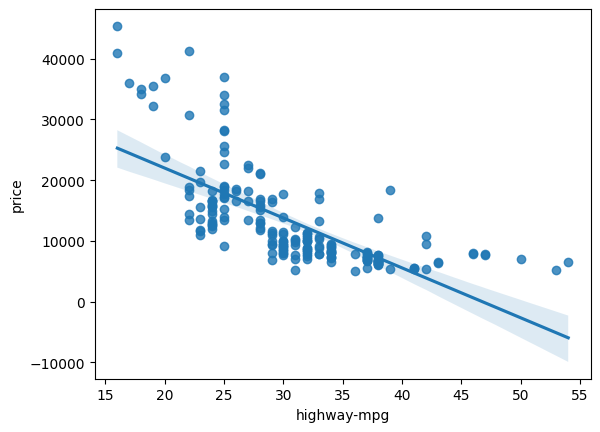

In [10]:
sns.regplot(data=df,x='highway-mpg',y='price')

##### So Highway MPG is negatively correlated with price with a score of -0.704

In [11]:
df[['highway-mpg','price']].corr()

,highway-mpg,price
highway-mpg,1.000000,-0.704692
price,-0.704692,1.000000


#### looking at peak-rpm as a predictor of price

<Axes: xlabel='peak-rpm', ylabel='price'>

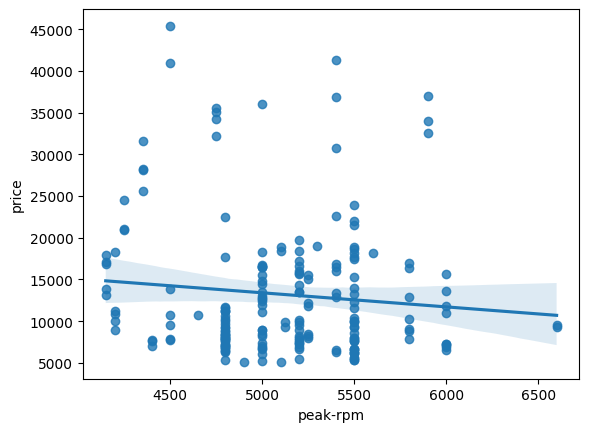

In [13]:
sns.regplot(data=df,x='peak-rpm',y='price')

##### So Peak rpm is not a good indicator at all of the price since the reg-line is close to horizontal. Also, the data points are very scattered and far from the fitted line, showing lots of variability. Therefore it's not a reliable variable

In [15]:
df[['peak-rpm','price']].corr()

,peak-rpm,price
peak-rpm,1.000000,-0.101616
price,-0.101616,1.000000


#### Finding correlation between stroke and price next

In [16]:
df[['stroke','price']].corr()

,stroke,price
stroke,1.00000,0.08231
price,0.08231,1.00000


<Axes: xlabel='stroke', ylabel='price'>

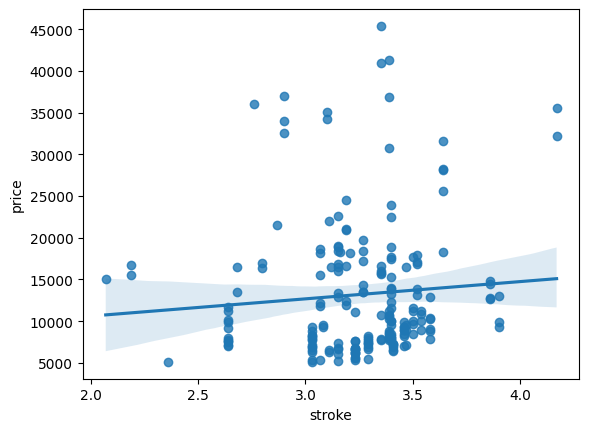

In [17]:
sns.regplot(data=df,x='stroke',y='price')

##### There is weak correlation between the variable stroke and price as such regression will not work well.

#### Visualising the categorical variables like body-style with price using a boxplot

<Axes: xlabel='body-style', ylabel='price'>

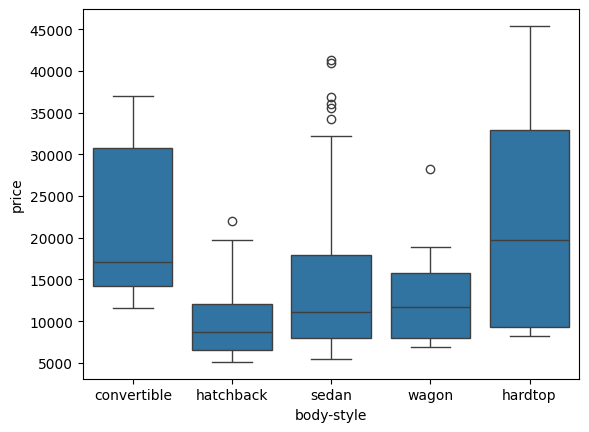

In [19]:
sns.boxplot(data=df,x='body-style',y='price')

##### we see that the distributions of price between the different body style categories have a significant overlap, so body-style would not be a good predictor of price

#### Next, examining engine-location and price

<Axes: xlabel='engine-location', ylabel='price'>

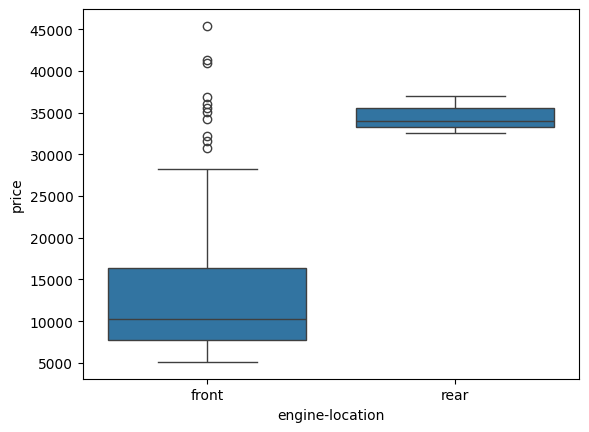

In [20]:
sns.boxplot(data=df,x='engine-location',y='price')

##### The distribution of price between these two engine-location categories, front and rear are distinct enough to take engine-location as a potential good predictor of price

#### Examining drive-wheels and price:

<Axes: xlabel='drive-wheels', ylabel='price'>

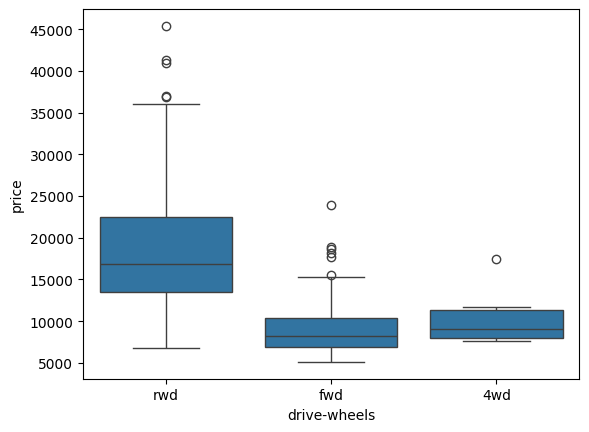

In [21]:
sns.boxplot(data=df,x='drive-wheels',y='price')

##### Here the distribution of price between the different drive-wheels categories differs. As such, drive wheels could potentially be a predictor of price

### Descriptive Stats Analysis
##

In [22]:
df.describe()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,diesel,gas
count,201.000000,201.00000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,197.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000
mean,0.840796,122.00000,98.797015,0.837102,0.915126,53.766667,2555.666667,126.875622,3.330692,3.256904,10.164279,103.405534,5117.665368,25.179104,30.686567,13207.129353,9.944145,0.099502,0.900498
std,1.254802,31.99625,6.066366,0.059213,0.029187,2.447822,517.296727,41.546834,0.268072,0.319256,4.004965,37.365700,478.113805,6.423220,6.815150,7947.066342,2.534599,0.300083,0.300083
min,-2.000000,65.00000,86.600000,0.678039,0.837500,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000,4.795918,0.000000,0.000000
25%,0.000000,101.00000,94.500000,0.801538,0.890278,52.000000,2169.000000,98.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000,7.833333,0.000000,1.000000
50%,1.000000,122.00000,97.000000,0.832292,0.909722,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5125.369458,24.000000,30.000000,10295.000000,9.791667,0.000000,1.000000
75%,2.000000,137.00000,102.400000,0.881788,0.925000,55.500000,2926.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000,12.368421,0.000000,1.000000
max,3.000000,256.00000,120.900000,1.000000,1.000000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,262.000000,6600.000000,49.000000,54.000000,45400.000000,18.076923,1.000000,1.000000


In [24]:
df.describe(include=['object'])

,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,engine-type,num-of-cylinders,fuel-system,horsepower-binned
count,201,201,201,201,201,201,201,201,201,200
unique,22,2,2,5,3,2,6,7,8,3
top,toyota,std,four,sedan,fwd,front,ohc,four,mpfi,Low
freq,32,165,115,94,118,198,145,157,92,115


In [34]:
df['drive-wheels'].value_counts().to_frame('count')

,count
drive-wheels,
fwd,118
rwd,75
4wd,8


In [35]:
drive_wheels_counts = df['drive-wheels'].value_counts().to_frame()
drive_wheels_counts.reset_index(inplace=True)
drive_wheels_counts=drive_wheels_counts.rename(columns={'drive-wheels': 'value_counts'})
drive_wheels_counts

,value_counts,count
0,fwd,118
1,rwd,75
2,4wd,8


In [36]:
drive_wheels_counts.index.name = 'drive-wheels'
drive_wheels_counts

,value_counts,count
drive-wheels,,
0,fwd,118
1,rwd,75
2,4wd,8


In [33]:
engine_loc_counts=df['engine-location'].value_counts().to_frame()
engine_loc_counts.rename(columns={'engine-location':'value_counts'},inplace=True)
engine_loc_counts.index.name='engine-location'
engine_loc_counts.head(10)

,count
engine-location,
front,198
rear,3


##### After examining above two results it is evident that engine location is not a good predictor of price. This is because we only have three cars with rear engine and 198 with front engine, so the result is skewed. Thus, we are not able to draw any conclusions about the engine location

### Looking at which type of drive wheel is most valuable by grouping drive-wheels and then taking there average

In [37]:
df['drive-wheels'].unique()

array(['rwd', 'fwd', '4wd'], dtype=object)

In [39]:
df_g1=df[['drive-wheels','body-style','price']]
df_g1

,drive-wheels,body-style,price
0,rwd,convertible,13495.0
1,rwd,convertible,16500.0
2,rwd,hatchback,16500.0
3,fwd,sedan,13950.0
4,4wd,sedan,17450.0
...,...,...,...
196,rwd,sedan,16845.0
197,rwd,sedan,19045.0
198,rwd,sedan,21485.0
199,rwd,sedan,22470.0


In [40]:
df_grouped=df_g1.groupby(['drive-wheels'],as_index=False).agg({'price':'mean'})

In [41]:
df_grouped

,drive-wheels,price
0,4wd,10241.000000
1,fwd,9244.779661
2,rwd,19757.613333


##### from the data, RWD vehicles are on average the most expensive, while all and front wheel are almost same in price on average

#### Grouping by multiple variables:-

In [45]:
df_gptest=df[['drive-wheels','body-style','price']]
gt1=df_gptest.groupby(['drive-wheels','body-style'],as_index=False).mean()
gt1

,drive-wheels,body-style,price
0,4wd,hatchback,7603.000000
1,4wd,sedan,12647.333333
2,4wd,wagon,9095.750000
3,fwd,convertible,11595.000000
4,fwd,hardtop,8249.000000
5,fwd,hatchback,8396.387755
6,fwd,sedan,9811.800000
7,fwd,wagon,9997.333333
8,rwd,convertible,23949.600000
9,rwd,hardtop,24202.714286


##### Using a pivot table now on this group:-

In [46]:
grouped_pivot=gt1.pivot(index='drive-wheels',columns='body-style')
grouped_pivot

price                                            \
body-style   convertible       hardtop     hatchback         sedan   
drive-wheels                                                         
4wd                  NaN           NaN   7603.000000  12647.333333   
fwd              11595.0   8249.000000   8396.387755   9811.800000   
rwd              23949.6  24202.714286  14337.777778  21711.833333   

                            
body-style           wagon  
drive-wheels                
4wd            9095.750000  
fwd            9997.333333  
rwd           16994.222222

In [47]:
grouped_pivot=grouped_pivot.fillna(0)
grouped_pivot

price                                            \
body-style   convertible       hardtop     hatchback         sedan   
drive-wheels                                                         
4wd                  0.0      0.000000   7603.000000  12647.333333   
fwd              11595.0   8249.000000   8396.387755   9811.800000   
rwd              23949.6  24202.714286  14337.777778  21711.833333   

                            
body-style           wagon  
drive-wheels                
4wd            9095.750000  
fwd            9997.333333  
rwd           16994.222222

#### Similarly, using the groupby on body style to find the average price

In [49]:
df_gptest2=df[['body-style','price']]
grouped_test_bs=df_gptest2.groupby(['body-style'],as_index=False).mean()
grouped_test_bs

,body-style,price
0,convertible,21890.500000
1,hardtop,22208.500000
2,hatchback,9957.441176
3,sedan,14459.755319
4,wagon,12371.960000


#### Using a heatmap to visualize the relationship between Body Style vs Price

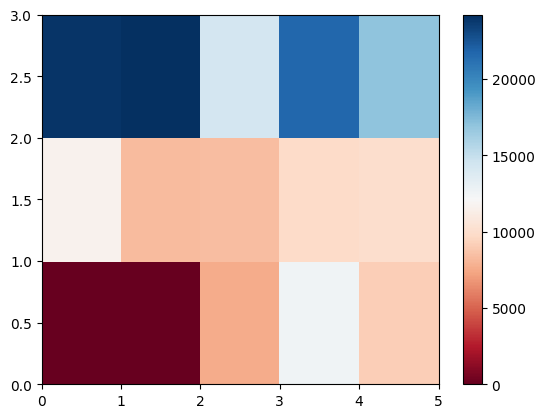

In [50]:
plt.pcolor(grouped_pivot,cmap='RdBu')
plt.colorbar()
plt.show()

##### The heat map plots the target variable price propotional to colour with respect tot he variables drive-wheel and body-style on the vertical and horizontal axis. This allows us to visualise how the price is related to drive-wheel and body-style

#### Plotting it again with proper labels, we get:

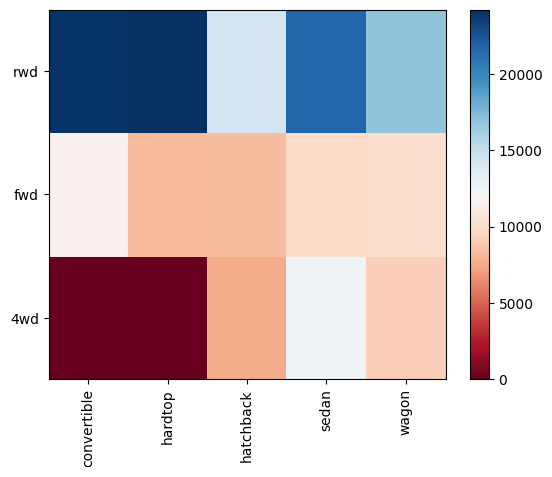

In [52]:
fig, ax=plt.subplots()
im=ax.pcolor(grouped_pivot,cmap='RdBu')

row_labels=grouped_pivot.columns.levels[1]
col_labels=grouped_pivot.index

ax.set_xticks(np.arange(grouped_pivot.shape[1])+0.5,minor=False)
ax.set_yticks(np.arange(grouped_pivot.shape[0])+0.5,minor=False)

ax.set_xticklabels(row_labels,minor=False)
ax.set_yticklabels(col_labels,minor=False)

plt.xticks(rotation=90)

fig.colorbar(im)
plt.show()

#### Now, lets have a look at the pearson correlation coefficient and P-value of wheel-base and price

In [55]:
from scipy import stats
p_coef,p_value=stats.pearsonr(df['wheel-base'],df['price'])
print("The pearson Coefficient is :",p_coef," with a P-value of :",p_value)

The pearson Coefficient is : 0.584641822265508  with a P-value of : 8.076488270732847e-20


##### the p-value is <0.001, so the correlation b/w wheel-base and price is statistically significant, although the linear replationship isn't extremely strong

#### Horsepower VS Price

In [56]:
p_coef,_value=stats.pearsonr(df['horsepower'],df['price'])
print("The pearson Coefficient is:",p_coef," with a P-value of :",p_value)

The pearson Coefficient is: 0.8095745670036562  with a P-value of : 8.076488270732847e-20


##### since p-value is <0.001, the correlation is significant and the linear relationship is quite strong

#### Length VS Price

In [58]:
p_coef, p_value=stats.pearsonr(df['length'],df['price'])
print("The pearson Coefficient is:",p_coef," with a P-value of :",p_value)

The pearson Coefficient is: 0.6906283804483639  with a P-value of : 8.016477466159293e-30


##### since p-value is <0.001, the correlation between length and price is statistically significant and linear relationship is moderately strong(~0.0691)

#### Width VS Price

In [59]:
p_coef, p_value=stats.pearsonr(df['width'],df['price'])
print("The pearson Coefficient is:",p_coef," with a P-value of :",p_value)

The pearson Coefficient is: 0.7512653440522675  with a P-value of : 9.200335510480586e-38


##### the p-value is < 0.001, the correlation between width and price is statistically significant, and the linear relationship is quite strong (~0.751)

#### Curb-weight VS Price

In [60]:
p_coef, p_value=stats.pearsonr(df['curb-weight'],df['price'])
print("The pearson Coefficient is:",p_coef," with a P-value of :",p_value)

The pearson Coefficient is: 0.8344145257702844  with a P-value of : 2.189577238893924e-53


##### the p-value is<0.001, the correlation between curb-weight and price is statistically significant, and the linear relationship is quite strong (~0.834).

#### Engine-size VS Price

In [61]:
p_coef, p_value=stats.pearsonr(df['engine-size'],df['price'])
print("The pearson Coefficient is:",p_coef," with a P-value of :",p_value)

The pearson Coefficient is: 0.8723351674455184  with a P-value of : 9.26549162219869e-64


#####   the p-value is<0.001, the correlation between engine-size and price is statistically significant, and the linear relationship is very strong (~0.872).

#### Bore VS Price

In [62]:
p_coef, p_value=stats.pearsonr(df['bore'],df['price'])
print("The pearson Coefficient is:",p_coef," with a P-value of :",p_value)

The pearson Coefficient is: 0.5431553832626603  with a P-value of : 8.049189483935274e-17


##### the p-value is<0.001, the correlation between bore and price is statistically significant, but the linear relationship is only modera<(~0.521).

#### City-mpg VS Price

In [63]:
p_coef, p_value=stats.pearsonr(df['city-mpg'],df['price'])
print("The pearson Coefficient is:",p_coef," with a P-value of :",p_value)

The pearson Coefficient is: -0.686571006784468  with a P-value of : 2.3211320655675065e-29


#####  the p-value is<0.001, the correlation between city-mpg and price is statistically significant, and the coefficient of about -0.687 shows that the relationship is negative and moderately strong.

#### Highway-mpg VS Price

In [64]:
p_coef, p_value=stats.pearsonr(df['highway-mpg'],df['price'])
print("The pearson Coefficient is:",p_coef," with a P-value of :",p_value)

The pearson Coefficient is: -0.7046922650589531  with a P-value of : 1.749547114447559e-31


#####  the p-value is < 0.001, the correlation between highway-mpg and price is statistically significant, and the coefficient of about -0.705 shows that the relationship is negative and moderately strong.

### Conclusion: Important Variables
##### we now have a better idea of what our data looks like and which variables are important to take into account when predicting the car price. we can further narrow it down to the following variables:-

##### Continous numerical variables:
##### Length
##### Width
##### Curb-weight
##### Engine-size
##### Horsepower
##### City-mpg
##### Highway-mpg
##### Bore

##### Categorical Variables:
##### Drive-wheels

##### we can now feed the model with variables that meaningfully affect our target variable and impro